# 2×2 CIG Curves (Excluding CCL)

This notebook builds a 2×2 panel of cumulative information gain (CIG) curves for the four non-CCL datasets using the exports from `notebooks/cumulative_likelihood_over_time.ipynb`.

Features:
- Loads the per-dataset curve CSVs from `notebooks/metrics/cumulative_likelihood_over_time` by default.
- Excludes `CCL` and plots `CB_HAB1a`, `CB_HAB4`, `PNR_1z`, and `St1-2018`.
- Supports plotting from the validation-set start, test-set start, NLL-window start, or the full available curve.
- Saves a publication-style PDF/PNG under `notebooks/figs/cumulative_likelihood_over_time`.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bootstrap import path so notebook can import project modules when started from notebook dir.
cwd = Path.cwd().resolve()
for candidate in (cwd, cwd.parent):
    if (candidate / 'src').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.runtime_utils import resolve_project_root
from src.utils.tpp_experiments import load_tpp_catalog

PROJECT_ROOT = resolve_project_root()
NOTEBOOK_NAME = 'cumulative_likelihood_over_time'
METRIC_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'metrics' / NOTEBOOK_NAME
FIG_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / NOTEBOOK_NAME
FIG_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'METRIC_EXPORT_DIR = {METRIC_EXPORT_DIR}')
print(f'FIG_EXPORT_DIR = {FIG_EXPORT_DIR}')


PROJECT_ROOT = /home/yzzhang/pjt/chuandian_eq
METRIC_EXPORT_DIR = /home/yzzhang/pjt/chuandian_eq/notebooks/metrics/cumulative_likelihood_over_time
FIG_EXPORT_DIR = /home/yzzhang/pjt/chuandian_eq/notebooks/figs/cumulative_likelihood_over_time


## Configuration

Set `PLOT_START_MODE` to control the left edge of each subplot:
- `'val'`: start from the validation split boundary.
- `'test'`: start from the test split boundary.
- `'nll'`: start from the first available curve point; for the existing exports this is near zero because the reference notebook resets `t_nll_start`.
- `'full'`: same as `'nll'`, kept as an explicit readability option.

For split-relative plots, `RESET_Y_AT_PLOT_START=True` subtracts each model's value at the crop start so all curves begin at zero within that displayed window.


In [2]:
# Four datasets: all cumulative-likelihood-over-time exports except CCL.
DATASET_CONFIGS = [
    {'config_name': 'CB_HAB1a', 'dataset': 'CB_HAB1a', 'title': 'CB-HAB1a'},
    {'config_name': 'CB_HAB4', 'dataset': 'CB_HAB4', 'title': 'CB-HAB4'},
    {'config_name': 'PNR_1z', 'dataset': 'PNR_1z', 'title': 'PNR-1z'},
    {'config_name': 'St1_2018', 'dataset': 'St1-2018', 'title': 'St1-2018'},
]

SPLIT = 'test'
SEQ_INDEX = 0
PLOT_START_MODE = 'full'  # Options: 'val', 'test', 'nll', 'full'
RESET_Y_AT_PLOT_START = True

# The reference notebook exports CIG as cum_log_likelihood_delta/plot_value.
PLOT_VALUE_COLUMN = 'plot_value'
BASELINE_MODEL_LABEL = 'ETAS'
EXCLUDE_LABELS = {BASELINE_MODEL_LABEL}  # Hide the all-zero baseline line by default.

# Optional label selection/order. Use None to keep the CSV order after exclusions.
MODEL_LABEL_ORDER = [
    'ETAS+p',
    'ETAS+conv',
    'ETAS+mamba',
    'RECAST+p',
    'RECAST+conv',
    'RECAST+mamba',
    'ORACLE',
]
EXPECTED_MODEL_LABELS = set(MODEL_LABEL_ORDER or [])


# Visual encoding: color = background-feature family; line style = model family.
MODEL_STYLE_MAP = {
    'ETAS+p': {'color': '#1b9e77', 'linestyle': '-', 'linewidth': 1.75, 'alpha': 0.95},
    'RECAST+p': {'color': '#1b9e77', 'linestyle': '--', 'linewidth': 1.85, 'alpha': 0.95},
    'ETAS+conv': {'color': '#d95f02', 'linestyle': '-', 'linewidth': 1.75, 'alpha': 0.95},
    'RECAST+conv': {'color': '#d95f02', 'linestyle': '--', 'linewidth': 1.85, 'alpha': 0.95},
    'ETAS+mamba': {'color': '#7570b3', 'linestyle': '-', 'linewidth': 1.75, 'alpha': 0.95},
    'RECAST+mamba': {'color': '#7570b3', 'linestyle': '--', 'linewidth': 1.85, 'alpha': 0.95},
    'ORACLE': {'color': '#222222', 'linestyle': '-.', 'linewidth': 2.05, 'alpha': 0.95},
}
DIRECT_LABEL_CURVES = True
DIRECT_LABEL_FONTSIZE = 7.2
DIRECT_LABEL_X_OFFSET_FRAC = 0.012
FIGSIZE = (13.8, 5.0)
SHARE_Y = False
SAVE_PDF = True
SAVE_PNG = True
DPI = 300

if PLOT_START_MODE not in {'val', 'test', 'nll', 'full'}:
    raise ValueError("PLOT_START_MODE must be one of {'val', 'test', 'nll', 'full'}.")
if SPLIT != 'test':
    print('Warning: existing default exports are for SPLIT="test"; make sure matching CSVs exist.')


## Load Curves and Split Metadata

This section reads the exported curve CSVs and each catalog's split metadata. If a CSV is missing, first run `notebooks/cumulative_likelihood_over_time.ipynb` for that dataset/config.

In [3]:
def _curve_csv_path(dataset_name, split=SPLIT, seq_index=SEQ_INDEX):
    return METRIC_EXPORT_DIR / f'cum_log_likelihood_compare_{dataset_name}_{split}_{seq_index}_curves.csv'


def _metadata_boundary_days(meta, key_t, key_ts):
    """Return split boundary in days since catalog start when metadata is available."""
    if not hasattr(meta, 'get'):
        return None

    raw_t = meta.get(key_t)
    if raw_t is not None:
        freq = meta.get('freq')
        if freq is not None:
            try:
                return float(raw_t) * float(pd.Timedelta(freq) / pd.Timedelta('1D'))
            except Exception:
                return float(raw_t)
        return float(raw_t)

    start_ts = meta.get('start_ts')
    boundary_ts = meta.get(key_ts)
    freq = meta.get('freq')
    if start_ts is not None and boundary_ts is not None and freq is not None:
        try:
            raw_value = (pd.Timestamp(boundary_ts) - pd.Timestamp(start_ts)) / pd.Timedelta(freq)
            return float(raw_value) * float(pd.Timedelta(freq) / pd.Timedelta('1D'))
        except Exception:
            return None
    return None


def _load_catalog_meta(dataset_name):
    catalog_ds, registry_name, _ = load_tpp_catalog(
        dataset_name,
        base_dir=PROJECT_ROOT / 'data' / dataset_name,
        catalog_cfg={},
    )
    meta = getattr(catalog_ds, 'metadata', {})
    return meta, registry_name


def _plot_start_days(meta, curve_df, mode):
    if mode == 'val':
        value = _metadata_boundary_days(meta, 'val_start_t', 'val_start_ts')
    elif mode == 'test':
        value = _metadata_boundary_days(meta, 'test_start_t', 'test_start_ts')
    elif mode in {'nll', 'full'}:
        value = None
    else:
        raise ValueError(f'Unsupported mode: {mode}')

    if value is None:
        return float(curve_df['time_days'].min())
    return float(value)


loaded_datasets = []
for cfg in DATASET_CONFIGS:
    dataset_name = cfg['dataset']
    curve_path = _curve_csv_path(dataset_name)
    if not curve_path.exists():
        raise FileNotFoundError(
            f'Missing curve CSV for {dataset_name}: {curve_path}\n'
            f'Run notebooks/cumulative_likelihood_over_time.ipynb with MODEL_SPEC_CONFIG_NAME={cfg["config_name"]!r}, '
            f'SPLIT={SPLIT!r}, SEQ_INDEX={SEQ_INDEX} first.'
        )

    curve_df = pd.read_csv(curve_path)
    if curve_df.empty:
        raise ValueError(f'Curve CSV is empty: {curve_path}')
    required_cols = {'label', 'dataset', 'time_days', PLOT_VALUE_COLUMN}
    missing_cols = sorted(required_cols - set(curve_df.columns))
    if missing_cols:
        raise KeyError(f'{curve_path} is missing required columns: {missing_cols}')

    # Normalize Oracle label casing for plot ordering, styling, legend, and exports.
    curve_df['label'] = curve_df['label'].replace({'Oracle': 'ORACLE'})

    meta, registry_name = _load_catalog_meta(dataset_name)
    val_start_days = _metadata_boundary_days(meta, 'val_start_t', 'val_start_ts')
    test_start_days = _metadata_boundary_days(meta, 'test_start_t', 'test_start_ts')
    start_days = _plot_start_days(meta, curve_df, PLOT_START_MODE)

    loaded_datasets.append({
        **cfg,
        'curve_path': curve_path,
        'curve_df': curve_df,
        'meta': meta,
        'registry_name': registry_name,
        'val_start_days': val_start_days,
        'test_start_days': test_start_days,
        'plot_start_days': start_days,
    })

summary_rows = []
for item in loaded_datasets:
    df = item['curve_df']
    summary_rows.append({
        'dataset': item['dataset'],
        'title': item['title'],
        'registry': item['registry_name'],
        'rows': len(df),
        'labels': ', '.join(df['label'].drop_duplicates()),
        'min_days': float(df['time_days'].min()),
        'max_days': float(df['time_days'].max()),
        'val_start_days': item['val_start_days'],
        'test_start_days': item['test_start_days'],
        'plot_start_days': item['plot_start_days'],
        'curve_path': str(item['curve_path'].relative_to(PROJECT_ROOT)),
    })

summary_df = pd.DataFrame(summary_rows)
missing_by_dataset = {}
for item in loaded_datasets:
    available_labels = set(item['curve_df']['label'].dropna().unique()) - EXCLUDE_LABELS
    missing_labels = sorted(EXPECTED_MODEL_LABELS - available_labels)
    if missing_labels:
        missing_by_dataset[item['dataset']] = missing_labels

if missing_by_dataset:
    print('Warning: missing configured labels in curve CSVs; re-run cumulative_likelihood_over_time for these datasets if needed:')
    for dataset_name, missing_labels in missing_by_dataset.items():
        print(f'  - {dataset_name}: {missing_labels}')

summary_df


/home/yzzhang/pjt/chuandian_eq/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


,dataset,title,registry,rows,labels,min_days,max_days,val_start_days,test_start_days,plot_start_days,curve_path
0,CB_HAB1a,CB-HAB1a,CB_HAB1a-Standard,53624,"ETAS, ETAS+p, ETAS+conv, ETAS+mamba, RECAST+p,...",0.000001,46.748615,32.724028,39.736319,0.000001,notebooks/metrics/cumulative_likelihood_over_t...
1,CB_HAB4,CB-HAB4,CB_HAB4-Standard,37472,"ETAS, ETAS+p, ETAS+conv, ETAS+mamba, RECAST+p,...",0.000001,23.797220,17.985093,19.485093,0.000001,notebooks/metrics/cumulative_likelihood_over_t...
2,PNR_1z,PNR-1z,PNR_1z-Standard,49136,"ETAS, ETAS+p, ETAS+conv, ETAS+mamba, RECAST+p,...",0.000001,64.208336,37.666667,59.666667,0.000001,notebooks/metrics/cumulative_likelihood_over_t...
3,St1-2018,St1-2018,St1-2018-Standard,242024,"ETAS, ETAS+p, ETAS+conv, ETAS+mamba, RECAST+p,...",0.000001,78.772598,39.772612,45.772612,0.000001,notebooks/metrics/cumulative_likelihood_over_t...


## 2×2 Plot Helpers

In [4]:
def _panel_label_from_index(i: int) -> str:
    n = i + 1
    chars = []
    while n > 0:
        n, rem = divmod(n - 1, 26)
        chars.append(chr(ord('a') + rem))
    return f"({''.join(reversed(chars))})"


def _label_order_for_df(df):
    labels = [label for label in df['label'].drop_duplicates().tolist() if label not in EXCLUDE_LABELS]
    if MODEL_LABEL_ORDER is None:
        return labels
    ordered = [label for label in MODEL_LABEL_ORDER if label in labels]
    ordered.extend([label for label in labels if label not in ordered])
    return ordered


def _step_value_at_or_before(time_values, y_values, query_time):
    time_values = np.asarray(time_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)
    if time_values.size == 0:
        return 0.0
    idx = np.searchsorted(time_values, float(query_time), side='right') - 1
    idx = int(np.clip(idx, 0, time_values.size - 1))
    return float(y_values[idx])


def _prepare_label_curve(df, label, start_days, reset_y=True):
    sub = df[df['label'] == label].sort_values('time_days')
    if sub.empty:
        return None

    time_days = sub['time_days'].to_numpy(dtype=float)
    y_values = sub[PLOT_VALUE_COLUMN].to_numpy(dtype=float)
    start_days = float(start_days)
    y_at_start = _step_value_at_or_before(time_days, y_values, start_days)

    mask = time_days >= start_days
    cropped_t = time_days[mask]
    cropped_y = y_values[mask]

    # Preserve the right-continuous step value exactly at the crop boundary.
    if cropped_t.size == 0 or cropped_t[0] > start_days:
        cropped_t = np.concatenate([[start_days], cropped_t])
        cropped_y = np.concatenate([[y_at_start], cropped_y])
    elif cropped_t[0] < start_days:
        cropped_t[0] = start_days

    if reset_y:
        cropped_y = cropped_y - y_at_start

    cropped_t = cropped_t - start_days
    return cropped_t, cropped_y


def _model_style(label):
    return MODEL_STYLE_MAP.get(label, {'linewidth': 1.55})


def _add_direct_curve_labels(ax, label_curve_map):
    if not DIRECT_LABEL_CURVES or not label_curve_map:
        return

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    x_span = max(x_max - x_min, 1e-12)
    y_span = max(y_max - y_min, 1e-12)

    endpoints = []
    for label, (x, y, line) in label_curve_map.items():
        if len(x) == 0:
            continue
        endpoints.append([label, float(x[-1]), float(y[-1]), line])
    if not endpoints:
        return

    # Keep labels inside a right-side label lane, with deterministic non-overlap.
    endpoints.sort(key=lambda item: item[2])
    label_low = y_min + 0.07 * y_span
    label_high = y_max - 0.07 * y_span
    available = max(label_high - label_low, 1e-12)
    min_gap = min(0.075 * y_span, available / max(1, len(endpoints) - 1))

    target_y = np.array([item[2] for item in endpoints], dtype=float)
    target_y = np.clip(target_y, label_low, label_high)

    # Forward and backward passes avoid both bottom and top pile-ups.
    for i in range(1, len(target_y)):
        target_y[i] = max(target_y[i], target_y[i - 1] + min_gap)
    overflow = target_y[-1] - label_high
    if overflow > 0:
        target_y -= overflow
    for i in range(len(target_y) - 2, -1, -1):
        target_y[i] = min(target_y[i], target_y[i + 1] - min_gap)
    underflow = label_low - target_y[0]
    if underflow > 0:
        target_y += underflow
    target_y = np.clip(target_y, label_low, label_high)

    ax.set_xlim(x_min, x_max + 0.26 * x_span)
    text_x = x_max + 0.035 * x_span

    for (label, x_end, y_end, line), text_y in zip(endpoints, target_y):
        color = line.get_color()
        ax.plot(
            [x_end, text_x - 0.01 * x_span],
            [y_end, float(text_y)],
            color=color,
            linewidth=0.55,
            alpha=0.65,
            clip_on=False,
        )
        ax.text(
            text_x,
            float(text_y),
            label,
            color=color,
            fontsize=DIRECT_LABEL_FONTSIZE,
            va='center',
            ha='left',
            clip_on=False,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.65, pad=0.15),
        )


def _draw_split_markers(ax, item):
    start = float(item['plot_start_days'])
    markers = [
        ('Val', item['val_start_days']),
        ('Test', item['test_start_days']),
    ]
    _, x_max = ax.get_xlim()
    for label, boundary in markers:
        if boundary is None:
            continue
        x = float(boundary) - start
        if x <= 1e-9 or x >= x_max:
            continue
        ax.axvline(x, color='black', linestyle='--', linewidth=0.9, alpha=0.45, zorder=2)
        ax.text(
            x,
            0.985,
            label,
            transform=ax.get_xaxis_transform(),
            ha='center',
            va='top',
            fontsize=8,
            color='#333333',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.4),
            zorder=4,
        )


def _format_start_label(mode):
    return {
        'val': 'validation start',
        'test': 'test start',
        'nll': 'NLL-window start',
        'full': 'curve start',
    }[mode]


## Generate and Save Figure

Saved PDF: /home/yzzhang/pjt/chuandian_eq/notebooks/figs/cumulative_likelihood_over_time/cig_2x2_excluding_CCL_test_0_from_full_reset_y.pdf
Saved PNG: /home/yzzhang/pjt/chuandian_eq/notebooks/figs/cumulative_likelihood_over_time/cig_2x2_excluding_CCL_test_0_from_full_reset_y.png


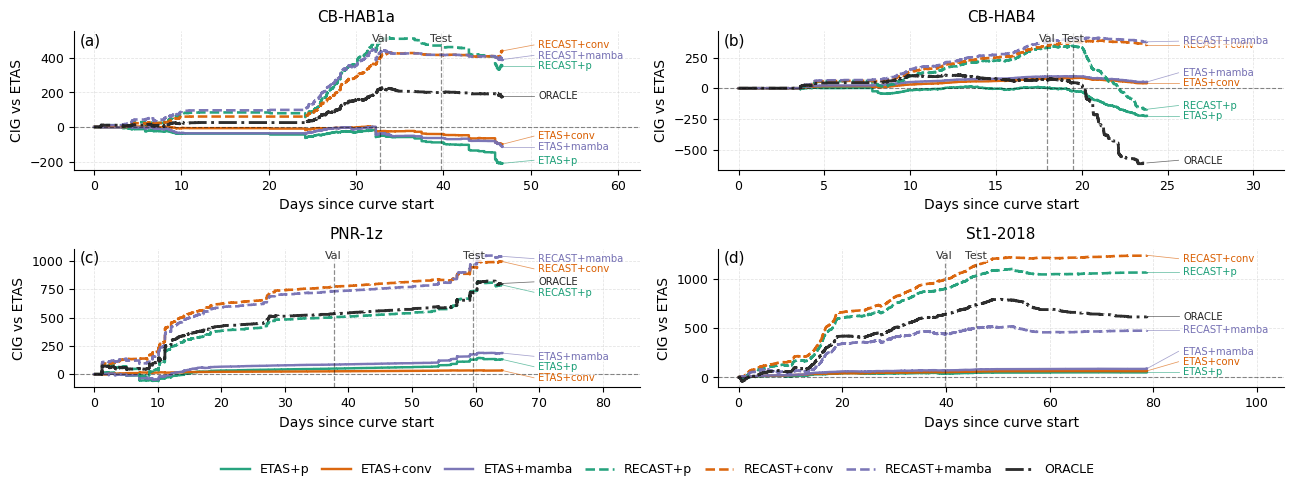

In [5]:
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE, sharey=SHARE_Y)
axes = axes.ravel()

handles_by_label = {}
for panel_idx, (ax, item) in enumerate(zip(axes, loaded_datasets)):
    df = item['curve_df']
    labels = _label_order_for_df(df)
    start_days = item['plot_start_days']

    label_curve_map = {}
    for label in labels:
        prepared = _prepare_label_curve(df, label, start_days, reset_y=RESET_Y_AT_PLOT_START)
        if prepared is None:
            continue
        x, y = prepared
        line = ax.step(x, y, where='post', label=label, **_model_style(label))[0]
        handles_by_label.setdefault(label, line)
        label_curve_map[label] = (x, y, line)

    ax.axhline(0.0, color='black', linestyle='--', linewidth=0.8, alpha=0.45)
    ax.set_title(item['title'], fontsize=11, pad=7)
    ax.text(0.01, 0.99, _panel_label_from_index(panel_idx), transform=ax.transAxes, va='top', ha='left', fontsize=11)
    ax.set_xlabel(f'Days since {_format_start_label(PLOT_START_MODE)}', fontsize=10)
    ax.set_ylabel('CIG vs ETAS' if RESET_Y_AT_PLOT_START else 'CIG vs ETAS (cumulative)', fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.55, alpha=0.35)
    ax.tick_params(axis='both', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    _add_direct_curve_labels(ax, label_curve_map)
    _draw_split_markers(ax, item)

# Turn off unused axes if DATASET_CONFIGS changes.
for ax in axes[len(loaded_datasets):]:
    ax.axis('off')

legend_labels = [label for label in (MODEL_LABEL_ORDER or list(handles_by_label)) if label in handles_by_label]
legend_labels.extend([label for label in handles_by_label if label not in legend_labels])
legend_handles = [handles_by_label[label] for label in legend_labels]

fig.legend(
    legend_handles,
    legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.005),
    ncol=min(7, max(1, len(legend_labels))),
    fontsize=9,
    frameon=False,
    columnspacing=1.0,
    handlelength=2.3,
)

start_suffix = f'from_{PLOT_START_MODE}'
y_suffix = 'reset_y' if RESET_Y_AT_PLOT_START else 'absolute_y'
fig.tight_layout(rect=(0.02, 0.09, 0.965, 0.99))

fig_stem = f'cig_2x2_excluding_CCL_{SPLIT}_{SEQ_INDEX}_{start_suffix}_{y_suffix}'
pdf_path = FIG_EXPORT_DIR / f'{fig_stem}.pdf'
png_path = FIG_EXPORT_DIR / f'{fig_stem}.png'

if SAVE_PDF:
    fig.savefig(pdf_path, dpi=DPI, bbox_inches='tight')
if SAVE_PNG:
    fig.savefig(png_path, dpi=DPI, bbox_inches='tight')

print(f'Saved PDF: {pdf_path}')
print(f'Saved PNG: {png_path}')
plt.show()


## 2×2 Injection and Event Count Overlay

Injection rate and earthquake counts are overlaid in each dataset panel with twin y-axes, rather than split into separate panels.


Loaded CB_HAB1a injection/count series from CB_HAB1a-Standard (raw_time_series).
Loaded CB_HAB4 injection/count series from CB_HAB4-Standard (raw_time_series).
Loaded PNR_1z injection/count series from PNR_1z-Standard (time_series).
Loaded St1-2018 injection/count series from St1-2018-Standard (raw_time_series).


/home/yzzhang/pjt/chuandian_eq/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Saved PDF: /home/yzzhang/pjt/chuandian_eq/notebooks/figs/cumulative_likelihood_over_time/injection_event_count_2x2_test_0_from_full.pdf
Saved PNG: /home/yzzhang/pjt/chuandian_eq/notebooks/figs/cumulative_likelihood_over_time/injection_event_count_2x2_test_0_from_full.png


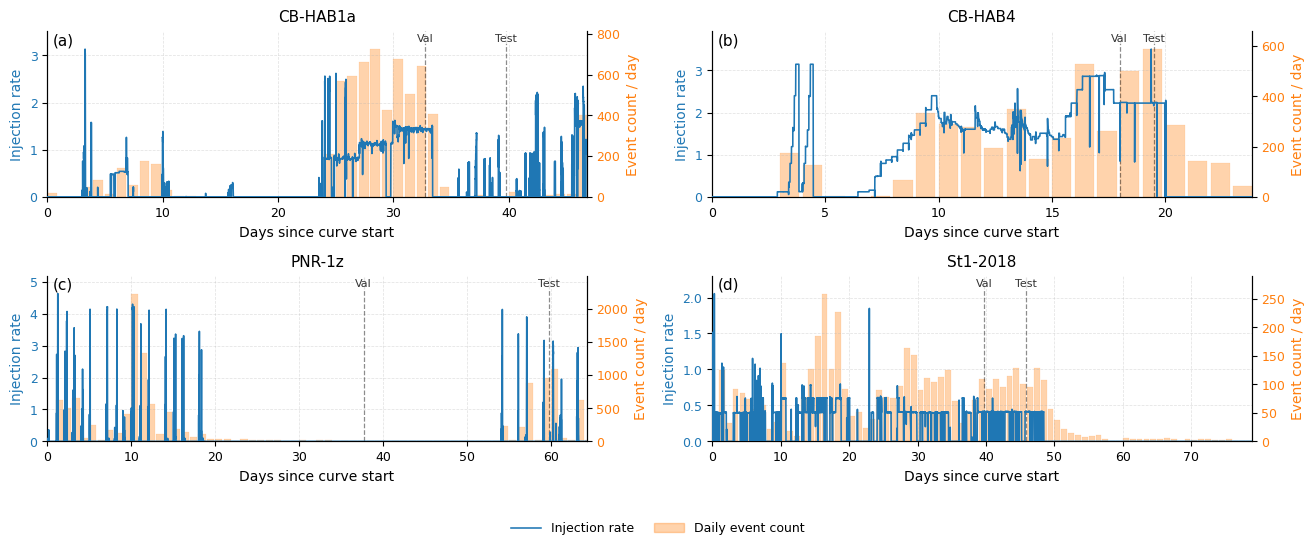

In [6]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Use the same catalog cache/config as the CIG curves so event counts match the plotted sequence.
# The extractor uses raw_time_series when available; otherwise it falls back to time_series.
INJECTION_COUNT_CATALOG_CFG = {}
INJECTION_COLOR = 'tab:blue'
COUNT_COLOR = 'tab:orange'
COUNT_ALPHA = 0.34
INJECTION_LINEWIDTH = 1.15
COUNT_DAILY_AGGREGATE = True
COUNT_BAR_WIDTH_DAYS = 0.85


def _to_numpy_array(value):
    if hasattr(value, 'detach'):
        value = value.detach().cpu().numpy()
    return np.asarray(value)


def _time_to_days_scale(meta) -> float:
    if not hasattr(meta, 'get'):
        return 1.0
    freq = meta.get('freq')
    if freq is None:
        return 1.0
    try:
        return float(pd.Timedelta(freq) / pd.Timedelta('1D'))
    except Exception:
        return 1.0


def _extract_injection_count_series(seq, metadata) -> dict:
    injection_source = 'raw_time_series'
    injection = getattr(seq, 'raw_time_series', None)
    inj_time = getattr(seq, 'raw_time_series_times', None)
    if injection is None or inj_time is None:
        injection_source = 'time_series'
        injection = getattr(seq, 'time_series', None)
        inj_time = getattr(seq, 'time_series_times', None)

    if injection is None or inj_time is None:
        raise ValueError('Selected sequence has no time_series/time_series_times for injection plotting.')

    inj_time = _to_numpy_array(inj_time).reshape(-1)
    injection_arr = _to_numpy_array(injection)
    if injection_arr.shape[0] != inj_time.shape[0]:
        raise ValueError(
            'Injection values and time stamps must have the same first dimension, got '
            f'{injection_arr.shape[0]} vs {inj_time.shape[0]}'
        )
    injection = injection_arr.reshape(inj_time.shape[0], -1)[:, 0]
    arrival_times = _to_numpy_array(seq.arrival_times).reshape(-1)

    if inj_time.shape[0] < 2:
        raise ValueError('time_series_times must contain at least 2 samples.')

    bin_counts, _ = np.histogram(arrival_times, bins=inj_time)
    injection_mid = 0.5 * (injection[1:] + injection[:-1])
    inj_time_mid = 0.5 * (inj_time[1:] + inj_time[:-1])
    scale = _time_to_days_scale(metadata)

    return {
        'injection_mid': injection_mid,
        'inj_time_mid_days': inj_time_mid * scale,
        'bin_counts': bin_counts,
        'injection_source': injection_source,
    }


def _load_injection_count_series(item) -> dict:
    candidate_standard = item['dataset'] + '-Standard'
    catalog_ds, registry_name, _ = load_tpp_catalog(
        item['dataset'],
        base_dir=PROJECT_ROOT / 'data' / item['dataset'],
        catalog_cfg=INJECTION_COUNT_CATALOG_CFG,
        candidates=[candidate_standard, item['dataset']],
    )
    series = _extract_injection_count_series(catalog_ds.full_sequence, catalog_ds.metadata)
    return {'series': series, 'registry_name': registry_name, 'metadata': catalog_ds.metadata}


def _crop_injection_count_to_item(series: dict, item: dict) -> dict:
    start_days = float(item['plot_start_days'])
    end_days = float(item['curve_df']['time_days'].max())
    x_days = np.asarray(series['inj_time_mid_days'], dtype=float)
    mask = (x_days >= start_days) & (x_days <= end_days)
    return {
        'x': x_days[mask] - start_days,
        'injection': np.asarray(series['injection_mid'], dtype=float)[mask],
        'counts': np.asarray(series['bin_counts'], dtype=float)[mask],
        'xmax': max(end_days - start_days, 1e-9),
    }


def _set_positive_ylim(ax, values, headroom: float = 0.12):
    arr = np.asarray(values, dtype=float).reshape(-1)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return
    y_min = 0.0 if np.nanmin(arr) >= 0 else float(np.nanmin(arr))
    y_max = float(np.nanmax(arr))
    span = y_max - y_min
    pad = max(span * headroom, abs(y_max) * headroom, 1e-6)
    ax.set_ylim(y_min, y_max + pad)


def _daily_count_bars(x, counts):
    x = np.asarray(x, dtype=float)
    counts = np.asarray(counts, dtype=float)
    if x.size == 0:
        return np.array([]), np.array([])
    day_index = np.floor(np.maximum(x, 0.0)).astype(int)
    daily = pd.Series(counts).groupby(day_index).sum()
    return daily.index.to_numpy(dtype=float), daily.to_numpy(dtype=float)


def _plot_injection_count_panel(ax, item, overlay_item, panel_idx: int):
    cropped = _crop_injection_count_to_item(overlay_item['series'], item)
    x = cropped['x']
    injection = cropped['injection']
    counts = cropped['counts']

    ax_count = ax.twinx()
    ax.set_zorder(ax_count.get_zorder() + 1)
    ax.patch.set_visible(False)

    if COUNT_DAILY_AGGREGATE:
        count_x, count_y = _daily_count_bars(x, counts)
        ax_count.bar(
            count_x,
            count_y,
            width=COUNT_BAR_WIDTH_DAYS,
            align='edge',
            color=COUNT_COLOR,
            edgecolor=COUNT_COLOR,
            linewidth=0.2,
            alpha=COUNT_ALPHA,
            label='Daily event count',
            zorder=1,
        )
        count_values = count_y
    else:
        nz = counts > 0
        ax_count.vlines(x[nz], 0, counts[nz], color=COUNT_COLOR, alpha=0.72, linewidth=0.7, label='Event count')
        count_values = counts[nz]

    ax.plot(x, injection, color=INJECTION_COLOR, linewidth=INJECTION_LINEWIDTH, label='Injection rate', zorder=3)
    ax.set_xlim(0, cropped['xmax'])
    _set_positive_ylim(ax, injection)
    _set_positive_ylim(ax_count, count_values)

    ax.set_title(item['title'], fontsize=11, pad=7)
    ax.text(0.01, 0.99, _panel_label_from_index(panel_idx), transform=ax.transAxes, va='top', ha='left', fontsize=11)
    ax.set_xlabel(f'Days since {_format_start_label(PLOT_START_MODE)}', fontsize=10)
    ax.set_ylabel('Injection rate', color=INJECTION_COLOR, fontsize=10)
    ax_count.set_ylabel('Event count / day' if COUNT_DAILY_AGGREGATE else 'Event count', color=COUNT_COLOR, fontsize=10)
    ax.tick_params(axis='y', labelcolor=INJECTION_COLOR, labelsize=9)
    ax_count.tick_params(axis='y', labelcolor=COUNT_COLOR, labelsize=9)
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(True, linestyle='--', linewidth=0.55, alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax_count.spines['top'].set_visible(False)
    _draw_split_markers(ax, item)


injection_count_overlays = {}
for item in loaded_datasets:
    injection_count_overlays[item['dataset']] = _load_injection_count_series(item)
    source = injection_count_overlays[item['dataset']]['series']['injection_source']
    registry = injection_count_overlays[item['dataset']]['registry_name']
    print(f"Loaded {item['dataset']} injection/count series from {registry} ({source}).")

fig, axes = plt.subplots(2, 2, figsize=(13.8, 5.6), sharex=False, sharey=False)
axes = axes.ravel()
for panel_idx, (ax, item) in enumerate(zip(axes, loaded_datasets)):
    _plot_injection_count_panel(ax, item, injection_count_overlays[item['dataset']], panel_idx)

for ax in axes[len(loaded_datasets):]:
    ax.axis('off')

legend_handles = [
    Line2D([0], [0], color=INJECTION_COLOR, linewidth=INJECTION_LINEWIDTH, label='Injection rate'),
    Patch(facecolor=COUNT_COLOR, edgecolor=COUNT_COLOR, alpha=COUNT_ALPHA, label='Daily event count' if COUNT_DAILY_AGGREGATE else 'Event count'),
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.005),
    ncol=2,
    fontsize=9,
    frameon=False,
    columnspacing=1.6,
    handlelength=2.4,
)

start_suffix = f'from_{PLOT_START_MODE}'
fig.tight_layout(rect=(0.02, 0.09, 0.98, 0.99))
fig_stem = f'injection_event_count_2x2_{SPLIT}_{SEQ_INDEX}_{start_suffix}'
pdf_path = FIG_EXPORT_DIR / f'{fig_stem}.pdf'
png_path = FIG_EXPORT_DIR / f'{fig_stem}.png'

if SAVE_PDF:
    fig.savefig(pdf_path, dpi=DPI, bbox_inches='tight')
if SAVE_PNG:
    fig.savefig(png_path, dpi=DPI, bbox_inches='tight')

print(f'Saved PDF: {pdf_path}')
print(f'Saved PNG: {png_path}')
plt.show()


## Dataset Location Map

Set `DRAW_SPATIAL_LOCATION_MAP = False` to skip drawing the global PyGMT map; set `MAP_USE_PYGMT = False` to use the older matplotlib fallback.


Saved PDF: /home/yzzhang/pjt/chuandian_eq/notebooks/figs/cumulative_likelihood_over_time/dataset_location_map_pygmt_test_0.pdf
Saved PNG: /home/yzzhang/pjt/chuandian_eq/notebooks/figs/cumulative_likelihood_over_time/dataset_location_map_pygmt_test_0.png


,dataset,title,center_lat,center_lon,n_location_points,source
0,CB_HAB1a,CB-HAB1a,-27.815082,140.754044,23285,data/CB_HAB1a/processed/CB_HAB1a_eq_processed.csv
1,CB_HAB4,CB-HAB4,-27.810613,140.758835,20735,data/CB_HAB4/processed/CB_HAB4_eq_processed.csv
2,PNR_1z,PNR-1z,53.787200,-2.967280,38246,data/PNR_1z/raw/PNR_1z_catalog.csv
3,St1-2018,St1-2018,60.192904,24.837320,1986,data/St1-2018/processed/St1-2018_eq_processed....


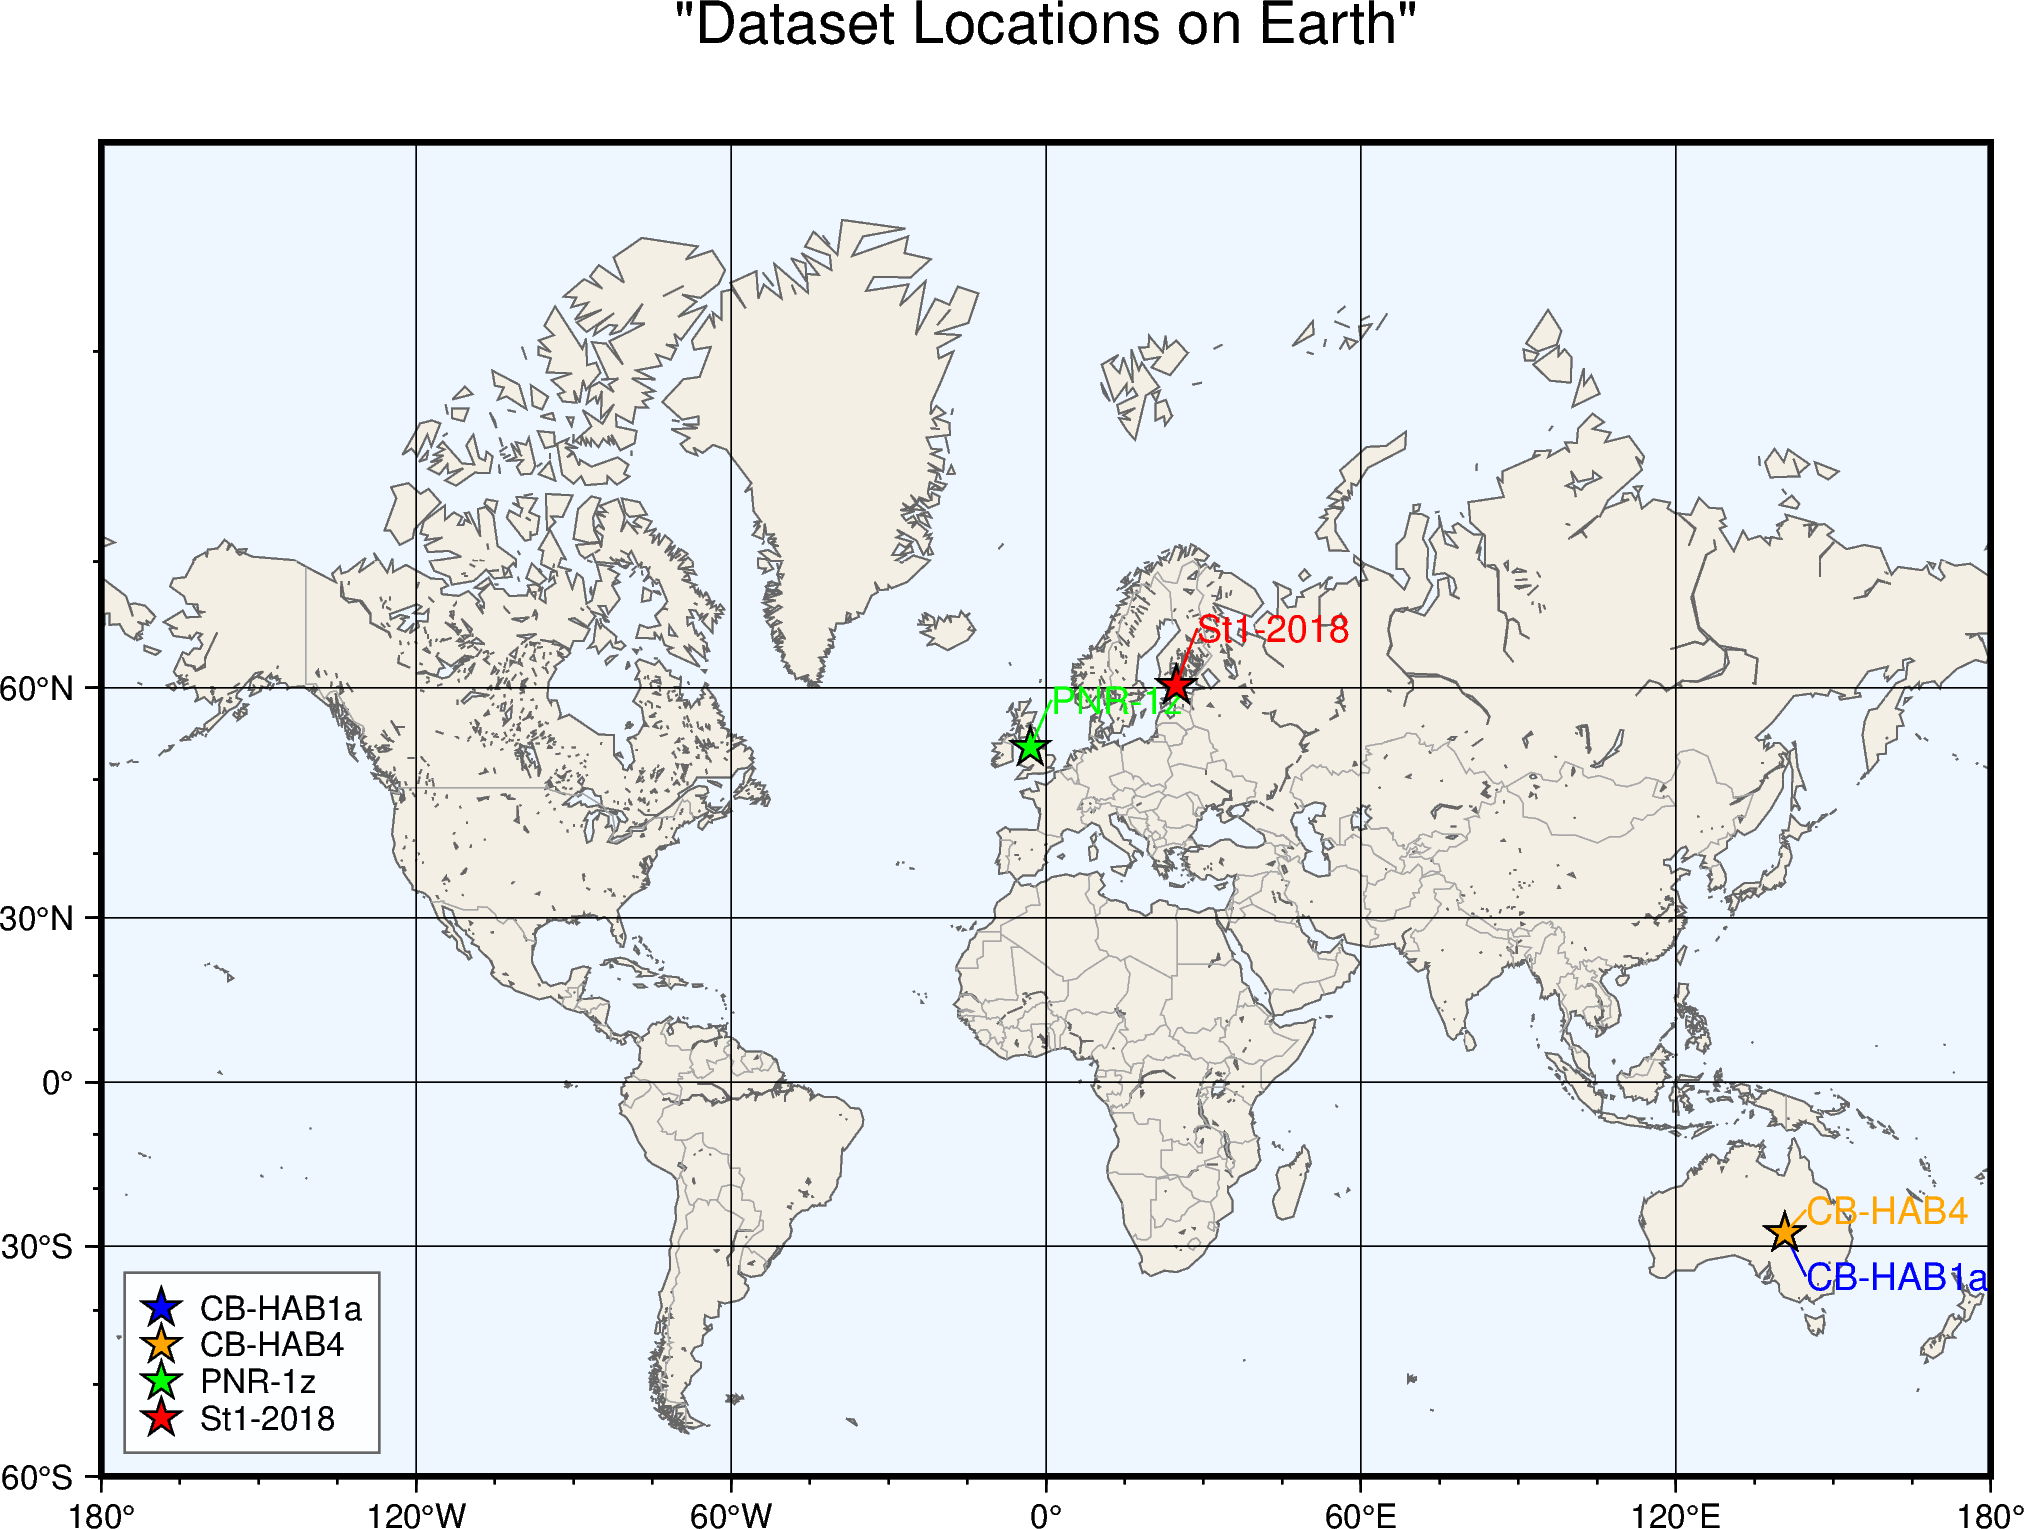

In [7]:
# Toggle this off if you only want the CIG and injection/event-count panels.
try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

DRAW_SPATIAL_LOCATION_MAP = True
MAP_WORLD_SHP = PROJECT_ROOT / 'data' / 'ne_10m_admin_0_countries' / 'ne_10m_admin_0_countries.shp'
MAP_DRAW_WORLD_POLYGONS = True  # Set False to use only the longitude/latitude grid background.
MAP_POINT_LIMIT_PER_DATASET = 300
MAP_LOCATION_FALLBACKS = {
    'St1-2018': {'lat': 60.1926, 'lon': 24.8363, 'source': 'fallback approximate project site'},
}
MAP_PROJECTED_CRS = {
    'St1-2018': 'EPSG:3879',  # Finnish GK25 / ETRS-GK25FIN; raw columns are northing/easting.
}
MAP_LABEL_OFFSETS = {
    'CB_HAB1a': (4.0, -7.0),
    'CB_HAB4': (4.0, 4.0),
    'PNR_1z': (4.0, 5.0),
    'St1-2018': (4.0, 5.0),
}
MAP_USE_PYGMT = True
MAP_PYGMT_REGION = [-180, 180, -60, 85]
MAP_PYGMT_PROJECTION = 'M16c'
MAP_PYGMT_TITLE = None
MAP_PYGMT_FRAME = ['xa60f30', 'ya30f15']
MAP_PYGMT_EXPORT_MARGIN_WESN = '0.35c/0.14c/0.32c/0.06c'
MAP_PYGMT_DISPLAY_WIDTH = 780
MAP_SHOW_LOCATION_POINTS = True
MAP_SHOW_GRID = False
MAP_PYGMT_COLORS = {
    'CB_HAB1a': 'blue',
    'CB_HAB4': 'orange',
    'PNR_1z': 'green',
    'St1-2018': 'red',
}


def _normalized_col_name(name: str) -> str:
    return str(name).strip().lower().replace('_', ' ').replace('-', ' ')


def _pick_first_column(df, candidates):
    normalized = {_normalized_col_name(col): col for col in df.columns}
    for candidate in candidates:
        col = normalized.get(_normalized_col_name(candidate))
        if col is not None:
            return col
    return None


def _dataset_location_files(dataset: str) -> list[Path]:
    base = PROJECT_ROOT / 'data' / dataset
    return [
        base / 'processed' / f'{dataset}_eq_processed.csv',
        base / 'raw' / f'{dataset}_catalog.csv',
        base / 'raw' / f'{dataset}_Eq.csv',
        base / 'raw' / f'{dataset}_Traj.csv',
    ]


def _lonlat_from_columns(df, dataset: str, source: str) -> pd.DataFrame | None:
    lat_col = _pick_first_column(df, ['latitude', 'lat', 'latitude deg', 'lat deg', 'Latitude (deg)', 'Lat_deg'])
    lon_col = _pick_first_column(df, ['longitude', 'lon', 'lng', 'longitude deg', 'lon deg', 'Longitude (deg)', 'Lon_deg'])
    if lat_col is None or lon_col is None:
        return None

    lat_raw = pd.to_numeric(df[lat_col], errors='coerce')
    lon_raw = pd.to_numeric(df[lon_col], errors='coerce')
    valid = np.isfinite(lat_raw) & np.isfinite(lon_raw)
    if not valid.any():
        return None

    lat = lat_raw[valid].to_numpy(dtype=float)
    lon = lon_raw[valid].to_numpy(dtype=float)
    degree_mask = (np.abs(lat) <= 90) & (np.abs(lon) <= 180)
    if degree_mask.any():
        return pd.DataFrame({'lat': lat[degree_mask], 'lon': lon[degree_mask], 'source': source})

    crs = MAP_PROJECTED_CRS.get(dataset)
    if crs is None:
        return None
    try:
        from pyproj import Transformer
        transformer = Transformer.from_crs(crs, 'EPSG:4326', always_xy=True)
        # Projected St1 columns are stored as northing/easting despite their names.
        lon_projected, lat_projected = transformer.transform(lon, lat)
    except Exception as exc:
        print(f'Could not transform projected coordinates for {dataset} ({crs}): {exc}')
        return None

    transformed_mask = (
        np.isfinite(lat_projected)
        & np.isfinite(lon_projected)
        & (np.abs(lat_projected) <= 90)
        & (np.abs(lon_projected) <= 180)
    )
    if not transformed_mask.any():
        return None
    return pd.DataFrame({
        'lat': lat_projected[transformed_mask],
        'lon': lon_projected[transformed_mask],
        'source': f'{source} transformed from {crs}',
    })


def _load_dataset_locations(dataset: str) -> pd.DataFrame:
    for path in _dataset_location_files(dataset):
        if not path.exists():
            continue
        try:
            df = pd.read_csv(path)
        except Exception as exc:
            print(f'Could not read {path}: {exc}')
            continue
        points = _lonlat_from_columns(df, dataset, str(path.relative_to(PROJECT_ROOT)))
        if points is not None and not points.empty:
            return points

    fallback = MAP_LOCATION_FALLBACKS.get(dataset)
    if fallback is None:
        raise ValueError(f'No finite location coordinates found for {dataset}.')
    return pd.DataFrame({'lat': [fallback['lat']], 'lon': [fallback['lon']], 'source': [fallback['source']]})


def _sample_location_points(points: pd.DataFrame, limit: int) -> pd.DataFrame:
    if len(points) <= limit:
        return points
    return points.sample(n=limit, random_state=0).sort_index()


def _read_shp_polygon_parts(shp_path: Path) -> list[np.ndarray]:
    import struct

    parts_out = []
    with open(shp_path, 'rb') as handle:
        handle.seek(100)
        while True:
            record_header = handle.read(8)
            if len(record_header) < 8:
                break
            _, content_words = struct.unpack('>2i', record_header)
            content = handle.read(content_words * 2)
            if len(content) < 44:
                continue
            shape_type = struct.unpack('<i', content[:4])[0]
            if shape_type not in {5, 15, 25, 31}:
                continue
            num_parts, num_points = struct.unpack('<2i', content[36:44])
            if num_parts <= 0 or num_points <= 0:
                continue
            parts_offset = 44
            points_offset = parts_offset + 4 * num_parts
            required = points_offset + 16 * num_points
            if len(content) < required:
                continue
            part_starts = struct.unpack(f'<{num_parts}i', content[parts_offset:points_offset])
            xy = np.frombuffer(content, dtype='<f8', count=num_points * 2, offset=points_offset).reshape(num_points, 2)
            for idx, start in enumerate(part_starts):
                end = part_starts[idx + 1] if idx + 1 < len(part_starts) else num_points
                part = xy[int(start):int(end)]
                if len(part) < 3:
                    continue
                step = max(1, len(part) // 450)
                parts_out.append(part[::step].copy())
    return parts_out


def _plot_world_background(ax):
    ax.set_facecolor('#eef7ff')
    if not MAP_DRAW_WORLD_POLYGONS:
        return 'longitude/latitude grid only'
    if MAP_WORLD_SHP.exists():
        try:
            from matplotlib.collections import PolyCollection
            polygons = _read_shp_polygon_parts(MAP_WORLD_SHP)
            if polygons:
                collection = PolyCollection(
                    polygons,
                    facecolor='#f3efe4',
                    edgecolor='0.62',
                    linewidths=0.28,
                    closed=True,
                    zorder=0,
                )
                ax.add_collection(collection)
                return 'Natural Earth country polygons'
        except Exception as exc:
            print(f'Could not draw world shapefile; falling back to lon/lat grid: {exc}')
    return 'longitude/latitude grid only'


def plot_dataset_location_map(loaded_items):
    location_items = []
    for item in loaded_items:
        points = _load_dataset_locations(item['dataset'])
        center = points[['lon', 'lat']].median()
        location_items.append({
            'dataset': item['dataset'],
            'title': item['title'],
            'points': points,
            'center_lon': float(center['lon']),
            'center_lat': float(center['lat']),
            'source': points['source'].iloc[0],
        })

    fig, ax = plt.subplots(figsize=(10.8, 5.8))
    bg_source = _plot_world_background(ax)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)
    ax.set_xlabel('Longitude (°)', fontsize=10)
    ax.set_ylabel('Latitude (°)', fontsize=10)
    if MAP_PYGMT_TITLE:
        ax.set_title(MAP_PYGMT_TITLE, fontsize=12, pad=8)
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.set_yticks(np.arange(-60, 91, 30))
    ax.tick_params(axis='both', which='major', pad=6)
    if MAP_SHOW_GRID:
        ax.grid(True, linestyle='--', linewidth=0.55, alpha=0.45, zorder=1)

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for idx, loc in enumerate(location_items):
        color = colors[idx % len(colors)]
        points = _sample_location_points(loc['points'], MAP_POINT_LIMIT_PER_DATASET)
        ax.scatter(points['lon'], points['lat'], s=8, color=color, alpha=0.22, linewidths=0, zorder=3)
        ax.scatter(
            loc['center_lon'],
            loc['center_lat'],
            s=86,
            color=color,
            marker='*',
            edgecolor='black',
            linewidth=0.65,
            zorder=4,
            label=loc['title'],
        )
        dx, dy = MAP_LABEL_OFFSETS.get(loc['dataset'], (4.0, 4.0))
        ax.annotate(
            loc['title'],
            xy=(loc['center_lon'], loc['center_lat']),
            xytext=(loc['center_lon'] + dx, loc['center_lat'] + dy),
            textcoords='data',
            fontsize=9,
            color=color,
            arrowprops=dict(arrowstyle='-', color=color, linewidth=0.7, alpha=0.8),
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.72, pad=0.25),
            zorder=5,
        )

    ax.legend(loc='lower left', fontsize=8.5, frameon=True, framealpha=0.92)
    ax.text(
        0.995,
        0.02,
        f'Background: {bg_source}',
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=7.5,
        color='0.35',
    )
    fig.tight_layout()

    fig_stem = f'dataset_location_map_{SPLIT}_{SEQ_INDEX}'
    pdf_path = FIG_EXPORT_DIR / f'{fig_stem}.pdf'
    png_path = FIG_EXPORT_DIR / f'{fig_stem}.png'
    if SAVE_PDF:
        fig.savefig(pdf_path, dpi=DPI, bbox_inches='tight')
    if SAVE_PNG:
        fig.savefig(png_path, dpi=DPI, bbox_inches='tight')

    print(f'Saved PDF: {pdf_path}')
    print(f'Saved PNG: {png_path}')
    display(pd.DataFrame([
        {
            'dataset': loc['dataset'],
            'title': loc['title'],
            'center_lat': loc['center_lat'],
            'center_lon': loc['center_lon'],
            'n_location_points': len(loc['points']),
            'source': loc['source'],
        }
        for loc in location_items
    ]))
    plt.show()


def _build_location_items(loaded_items):
    location_items = []
    for item in loaded_items:
        points = _load_dataset_locations(item['dataset'])
        center = points[['lon', 'lat']].median()
        location_items.append({
            'dataset': item['dataset'],
            'title': item['title'],
            'points': points,
            'center_lon': float(center['lon']),
            'center_lat': float(center['lat']),
            'source': points['source'].iloc[0],
        })
    return location_items


def _location_summary_df(location_items):
    return pd.DataFrame([
        {
            'dataset': loc['dataset'],
            'title': loc['title'],
            'center_lat': loc['center_lat'],
            'center_lon': loc['center_lon'],
            'n_location_points': len(loc['points']),
            'source': loc['source'],
        }
        for loc in location_items
    ])


def _require_pygmt():
    try:
        import pygmt
    except ImportError as exc:
        raise ImportError(
            'PyGMT is required for MAP_USE_PYGMT=True. Install it in this notebook kernel, '
            'for example with: conda install -c conda-forge pygmt'
        ) from exc
    return pygmt


def plot_dataset_location_map_pygmt(loaded_items):
    pygmt = _require_pygmt()
    location_items = _build_location_items(loaded_items)

    fig = pygmt.Figure()
    with pygmt.config(
        FONT_TITLE='13p,Helvetica-Bold',
        FONT_LABEL='10p,Helvetica',
        FONT_ANNOT_PRIMARY='8p,Helvetica',
        MAP_FRAME_TYPE='plain',
        MAP_ANNOT_OFFSET_PRIMARY='6p',
    ):
        fig.coast(
            region=MAP_PYGMT_REGION,
            projection=MAP_PYGMT_PROJECTION,
            frame=MAP_PYGMT_FRAME,
            land='#f3efe4',
            water='#eef7ff',
            shorelines='0.35p,gray40',
            borders='1/0.25p,gray65',
        )

        for loc in location_items:
            color = MAP_PYGMT_COLORS.get(loc['dataset'], 'black')
            if MAP_SHOW_LOCATION_POINTS:
                points = _sample_location_points(loc['points'], MAP_POINT_LIMIT_PER_DATASET)
                fig.plot(
                    x=points['lon'].to_numpy(dtype=float),
                    y=points['lat'].to_numpy(dtype=float),
                    style='c0.035c',
                    fill=color,
                    pen='0p',
                    transparency=70,
                )

            fig.plot(
                x=[loc['center_lon']],
                y=[loc['center_lat']],
                style='a0.34c',
                fill=color,
                pen='0.45p,black',
                label=loc['title'],
            )

            dx, dy = MAP_LABEL_OFFSETS.get(loc['dataset'], (4.0, 4.0))
            label_lon = loc['center_lon'] + dx
            label_lat = loc['center_lat'] + dy
            fig.plot(
                x=[loc['center_lon'], label_lon],
                y=[loc['center_lat'], label_lat],
                pen=f'0.45p,{color}',
            )
            fig.text(
                x=label_lon,
                y=label_lat,
                text=loc['title'],
                font=f'9p,Helvetica,{color}',
                justify='LM',
            )

        fig.legend(position='JBL+jBL+o0.2c/0.2c', box='+gwhite@15+p0.5p,gray40')

    fig_stem = f'dataset_location_map_pygmt_{SPLIT}_{SEQ_INDEX}'
    pdf_path = FIG_EXPORT_DIR / f'{fig_stem}.pdf'
    png_path = FIG_EXPORT_DIR / f'{fig_stem}.png'
    export_kwargs = {'resize': f'+m{MAP_PYGMT_EXPORT_MARGIN_WESN}'}
    if SAVE_PDF:
        fig.savefig(str(pdf_path), **export_kwargs)
    if SAVE_PNG:
        fig.savefig(str(png_path), **export_kwargs)

    print(f'Saved PDF: {pdf_path}')
    print(f'Saved PNG: {png_path}')
    display(_location_summary_df(location_items))
    fig.show(width=MAP_PYGMT_DISPLAY_WIDTH, **export_kwargs)


if DRAW_SPATIAL_LOCATION_MAP:
    if MAP_USE_PYGMT:
        plot_dataset_location_map_pygmt(loaded_datasets)
    else:
        plot_dataset_location_map(loaded_datasets)
else:
    print('DRAW_SPATIAL_LOCATION_MAP is False; skip dataset location map.')


## Optional: Save Cropped Long-Format Data

This cell exports the plotted 2×2 data after start-time cropping and optional y-reset, which is useful for downstream editing or reproduction.

In [8]:
EXPORT_CROPPED_CURVES = True
cropped_csv_path = METRIC_EXPORT_DIR / f'{fig_stem}_curves.csv'

if EXPORT_CROPPED_CURVES:
    rows = []
    for item in loaded_datasets:
        df = item['curve_df']
        labels = _label_order_for_df(df)
        start_days = item['plot_start_days']
        for label in labels:
            prepared = _prepare_label_curve(df, label, start_days, reset_y=RESET_Y_AT_PLOT_START)
            if prepared is None:
                continue
            x, y = prepared
            for xx, yy in zip(x, y):
                rows.append({
                    'dataset': item['dataset'],
                    'title': item['title'],
                    'label': label,
                    'days_since_plot_start': float(xx),
                    'plot_value': float(yy),
                    'plot_start_mode': PLOT_START_MODE,
                    'plot_start_days': float(start_days),
                    'reset_y_at_plot_start': bool(RESET_Y_AT_PLOT_START),
                    'source_curve_csv': str(item['curve_path'].relative_to(PROJECT_ROOT)),
                })
    cropped_df = pd.DataFrame(rows)
    cropped_df.to_csv(cropped_csv_path, index=False)
    print(f'Saved cropped curves CSV: {cropped_csv_path}')
    display(cropped_df.head())
else:
    print('EXPORT_CROPPED_CURVES=False; skipped CSV export.')


Saved cropped curves CSV: /home/yzzhang/pjt/chuandian_eq/notebooks/metrics/cumulative_likelihood_over_time/injection_event_count_2x2_test_0_from_full_curves.csv


,dataset,title,label,days_since_plot_start,plot_value,plot_start_mode,plot_start_days,reset_y_at_plot_start,source_curve_csv
0,CB_HAB1a,CB-HAB1a,ETAS+p,0.000000,0.000000,full,0.000001,True,notebooks/metrics/cumulative_likelihood_over_t...
1,CB_HAB1a,CB-HAB1a,ETAS+p,0.756758,-0.251840,full,0.000001,True,notebooks/metrics/cumulative_likelihood_over_t...
2,CB_HAB1a,CB-HAB1a,ETAS+p,0.781816,-0.695364,full,0.000001,True,notebooks/metrics/cumulative_likelihood_over_t...
3,CB_HAB1a,CB-HAB1a,ETAS+p,0.782337,-0.528478,full,0.000001,True,notebooks/metrics/cumulative_likelihood_over_t...
4,CB_HAB1a,CB-HAB1a,ETAS+p,0.783217,-0.495445,full,0.000001,True,notebooks/metrics/cumulative_likelihood_over_t...
